# Vision Transformers

copyright 2022, Denis Rothman, MIT License



#DALL-E
Reference, OpenAI:
https://github.com/openai/DALL-E/blob/master/notebooks/usage.ipynb



In [1]:
# !pip install folium==0.2.1
# !pip install torch==2.3.0+cu118 torchvision==0.18.0+cu101 -f https://download.pytorch.org/whl/torch_stable.html ftfy regex
# !pip install DALL-E
# !pip install ftfy
# !git clone https://github.com/openai/CLIP.git
%cd ./CLIP/

d:\WorkSpace\Python\Transformers-for-NLP\15.Chapter15\CLIP


Notes:<br>

**Generative Pre-trained Transformer(GPT)**

GPT is **Autoregressive** making predictions based on past values: prompt + completion. It is decoder-only model.

Each image token can attend to all of the text tokens in the model. The model contains **64 attention layers** and 12 billions parameters.

A **generative** model use joint probability distributions to produce new instances: p(X,Y) or P(X) if there are no labels <br>

A discriminative model discriminates between different instances in is based on a condition probablity p(Y|X)

In DALL-E, **identity mapping** will enable data to flow through the layers with residual functions, retaining information throughout the layers.


In [2]:
import io
import os, sys
import requests
import PIL

import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from dall_e          import map_pixels, unmap_pixels, load_model
from IPython.display import display, display_markdown

target_image_size = 256

def download_image(url):
    resp = requests.get(url)
    resp.raise_for_status()
    return PIL.Image.open(io.BytesIO(resp.content))

def preprocess(img):
    s = min(img.size)

    if s < target_image_size:
        raise ValueError(f'min dim for image {s} < {target_image_size}')

    r = target_image_size / s
    s = (round(r * img.size[1]), round(r * img.size[0]))
    img = TF.resize(img, s, interpolation=PIL.Image.LANCZOS)
    img = TF.center_crop(img, output_size=2 * [target_image_size])
    img = torch.unsqueeze(T.ToTensor()(img), 0)
    return map_pixels(img)

d:\WorkSpace\Python\Transformers-for-NLP\venv_38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# This can be changed to a GPU, e.g. 'cuda:0'.
dev = torch.device('cuda:0')

# For faster load times, download these files locally and use the local paths instead.
enc = load_model("https://cdn.openai.com/dall-e/encoder.pkl", dev)
dec = load_model("https://cdn.openai.com/dall-e/decoder.pkl", dev)

In [4]:
enc

Encoder(
  (blocks): Sequential(
    (input): Conv2d(n_in=3, n_out=256, kw=7, use_float16=True, device=device(type='cpu'), requires_grad=False)
    (group_1): Sequential(
      (block_1): EncoderBlock(
        (id_path): Identity()
        (res_path): Sequential(
          (relu_1): ReLU()
          (conv_1): Conv2d(n_in=256, n_out=64, kw=3, use_float16=True, device=device(type='cpu'), requires_grad=False)
          (relu_2): ReLU()
          (conv_2): Conv2d(n_in=64, n_out=64, kw=3, use_float16=True, device=device(type='cpu'), requires_grad=False)
          (relu_3): ReLU()
          (conv_3): Conv2d(n_in=64, n_out=64, kw=3, use_float16=True, device=device(type='cpu'), requires_grad=False)
          (relu_4): ReLU()
          (conv_4): Conv2d(n_in=64, n_out=256, kw=1, use_float16=True, device=device(type='cpu'), requires_grad=False)
        )
      )
      (block_2): EncoderBlock(
        (id_path): Identity()
        (res_path): Sequential(
          (relu_1): ReLU()
          (conv_

In [5]:
dec

Decoder(
  (blocks): Sequential(
    (input): Conv2d(n_in=8192, n_out=128, kw=1, use_float16=False, device=device(type='cpu'), requires_grad=False)
    (group_1): Sequential(
      (block_1): DecoderBlock(
        (id_path): Conv2d(n_in=128, n_out=2048, kw=1, use_float16=True, device=device(type='cpu'), requires_grad=False)
        (res_path): Sequential(
          (relu_1): ReLU()
          (conv_1): Conv2d(n_in=128, n_out=512, kw=1, use_float16=True, device=device(type='cpu'), requires_grad=False)
          (relu_2): ReLU()
          (conv_2): Conv2d(n_in=512, n_out=512, kw=3, use_float16=True, device=device(type='cpu'), requires_grad=False)
          (relu_3): ReLU()
          (conv_3): Conv2d(n_in=512, n_out=512, kw=3, use_float16=True, device=device(type='cpu'), requires_grad=False)
          (relu_4): ReLU()
          (conv_4): Conv2d(n_in=512, n_out=2048, kw=3, use_float16=True, device=device(type='cpu'), requires_grad=False)
        )
      )
      (block_2): DecoderBlock(
    

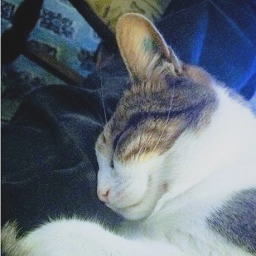

In [6]:
#Image of cat, creator and copyright Denis Rothman
x=preprocess(download_image('https://github.com/Denis2054/AI_Educational/blob/master/mycat.jpg?raw=true'))
display_markdown('Original image:')
display(T.ToPILImage(mode='RGB')(x[0]))

**September 10, 2023 update**

There are conflicts between the code requiring older versions of modules and the installed libraries.

[You can generate images with DALL-E 2 Notebook](https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/blob/main/Chapter17/Getting_Started_with_the_DALL_E_2_API.ipynb)   

In [7]:
"""
import torch.nn.functional as F

z_logits = enc(x)
z = torch.argmax(z_logits, axis=1)
z = F.one_hot(z, num_classes=enc.vocab_size).permute(0, 3, 1, 2).float()

x_stats = dec(z).float()
x_rec = unmap_pixels(torch.sigmoid(x_stats[:, :3]))
x_rec = T.ToPILImage(mode='RGB')(x_rec[0])

display_markdown('Reconstructed image:')
display(x_rec)
"""

"\nimport torch.nn.functional as F\n\nz_logits = enc(x)\nz = torch.argmax(z_logits, axis=1)\nz = F.one_hot(z, num_classes=enc.vocab_size).permute(0, 3, 1, 2).float()\n\nx_stats = dec(z).float()\nx_rec = unmap_pixels(torch.sigmoid(x_stats[:, :3]))\nx_rec = T.ToPILImage(mode='RGB')(x_rec[0])\n\ndisplay_markdown('Reconstructed image:')\ndisplay(x_rec)\n"